**Notebook Feito por:** MSc. Eng. Paulo de Souza Silva  
**Data:** Julho de 2026  
**Conteúdo retirado e adaptado de livros e artigos sobre Galerkin Descontínuo**  
**Agradecimentos:** Um agradecimento ao Prof. Dr. Alberto Nogueira pela disponibilização dos scripts em Python para DG 1D

# Aula 04 - Matriz de Diferenciacao via Vandermonde

Nos primeiros encontros, construímos um maquinário matemático poderoso: geramos polinômios ortogonais (Aula 01) e descobrimos como integrar perfeitamente funções utilizando as quadraturas de Gauss (Aulas 02 e 03).

A forma fraca discreta do nosso problema de Galerkin Descontínuo (DG) nos obriga a resolver balanços dentro de cada elemento que possuem a seguinte "cara" (ver Equação 23 do artigo de Moura):

$$ \int_{\Omega_e} \phi_j \frac{\partial u_h}{\partial t} dx + \int_{\Omega_e} \frac{\partial (\phi_j f(u_h))}{\partial x} dx - \int_{\Omega_e} \frac{\partial \phi_j}{\partial x} f(u_h) dx = 0 $$

Repare nos termos integrais do lado esquerdo:
1. No **primeiro termo**, teremos o produto de funções de base (uma vez que $u_h$ é construída a partir delas), o que dará origem à nossa **Matriz de Massa**.
2. No **segundo termo**, o Teorema Fundamental do Cálculo transforma a integral na avaliação das fronteiras do elemento (dando origem aos Fluxos Numéricos).
3. No **terceiro termo**, temos a presença explícita de uma **Derivada Espacial** $\left(\frac{\partial}{\partial x}\right)$ atrelada à função de teste, o que nos levará à **Matriz de Rigidez** (ou Matriz de Colocação).

> A pergunta que motiva o encontro de hoje e o próximo é: Como calculamos essa **derivada** com precisão computacional?

$\color{red}{\text{Observações:}}$

* Até o presente encontro nosso desenvolvimento esteve mais próximo da abordagem utilizada por Karniadakis.
* Neste encontro adotaremos uma abordagem mais próxima da utilizada por Hesthaven e Warburton, enfatizando a formulação nodal e a matriz de Vandermonde.
* O objetivo é mostrar que ambas as abordagens descrevem o mesmo espaço polinomial e conduzem, por caminhos diferentes, à mesma matriz de diferenciação, o que ficará evidente ao fim da aula 05.



In [1]:
from graphviz import Digraph

dot1 = Digraph()

dot1.node("A", "Espaço\nPolinomial")
dot1.node("B", "Base Modal")
dot1.node("C", "Legendre")
dot1.node("D", "Vandermonde")
dot1.node("E", "Base Nodal\n(Lagrange)")
dot1.node("F", "Matriz de\nDiferenciação")

dot1.edges([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","F")
])

dot1.attr(rankdir="LR")



dot2 = Digraph()

dot2.node("A", "Espaço\nPolinomial")
dot2.node("B", "Base Nodal")
dot2.node("C", "Interpolação de\nLagrange")
dot2.node("D", "Expansão em\nLegendre")
dot2.node("E", "Base Modal")
dot2.node("F", "Matriz de\nDiferenciação")

dot2.edges([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","F")
])

dot2.attr(rankdir="LR")

### Warburton

In [2]:
import os
# Adiciona a pasta padrão do Graphviz no PATH temporariamente
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

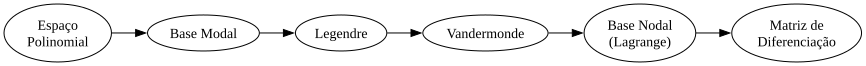

In [3]:
dot1

### Karniadakis

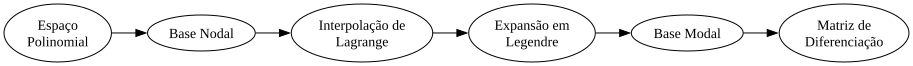

In [4]:
dot2

## Mundo Nodal vs Mundo Modal

Para resolver as equações no DG, assumimos que a solução global é a soma de soluções polinomiais construídas pedaço por pedaço. Dentro de um elemento padrão $r \in [-1, 1]$, existem duas formas principais de escrever essa aproximação: **Representação Modal** e **Representação Nodal**.

#### **O Dilema do DG:**  
A formulação Nodal é fantástica para a física:
* É mais fácil avaliar fluxos nas fronteiras
* Aplicar condições de contorno quando você lida com os valores reais de velocidade, pressão ou temperatura nos nós $u(r_i)$.

No entanto, a formulação Modal é insuperável para:
* **derivar**
* **integrar**  

Como já comentado, neste encontro seguiremos o viés do livro do Warburton, então vamos inicialmente evidenciar as duas representações assim como faz o autor.



#### **Representação Modal (O Mundo Espectral)**

A solução é vista como uma soma de funções de base, multiplicadas por **coeficientes modais** $\hat{u}_n$:
$$ u_h(r) = \sum_{n=1}^{N_p} \hat{u}_n \psi_{n}(r) $$

*Obs:* A função $\psi_{n}(r)$ pode ser:
* um monômio: $\psi_{n}(r)= r^{n-1}$;
* polinômios ortogonais (Legendre, Jacobi)
* polinômios ortonormais (Legendre, Jacobi).

A exemplo o polinômio de Legendre ortonormal é definido por $$\psi_{n}(r)= \tilde{P}_{n-1}(r)= \frac{P_{n-1}(r)}{\sqrt{\gamma_{n-1}}}$$

com $\gamma_{n-1} = \frac{2}{2n+1}$; a última opção **é escolhida** por conta de manter a ortogonalidade e norma 1.

Dessa forma os coeficientes modais acabam sendo expressos por

$$\hat{u}_n \approx \sum_{i=1}^{N_p} u(r_i) \tilde{P}_{n-1}(r_i)w_i$$

sendo $r_i$ e $w_i$ nossos nós e pesos de quadratura (GL ou GLL)!

#### **Representação Nodal (O Mundo Físico)**

A solução é vista a partir dos valores exatos que ela assume em pontos nodais específicos , utilizando aproximações interpoladoras

$$ u(\xi_i) = \sum_{n=1}^{N_p} \hat{u}_n \tilde{P}_{n-1}(\xi_i) $$

em que $\xi_i$ representa um conjunto de $N_P$ pontos distintos na malha. Observe que estes não precisam estar associados a quaisquer pontos de quadratura mas, ainda, continuamos a utilizar os Polinômios de Legendre.

Note que podemos escrever então essa expressão de forma matricial
$$\mathbf{u} = \mathcal{V} \hat{\mathbf{u}}$$
em que
$$\mathcal{V}_{ij} = \tilde{P}_{j-1}(\xi_i), \ \hat{\mathbf{u}}_i = \hat{u}_i, \ \mathbf{u}_i = u(\xi_i)$$

Essa matriz ($\mathcal{V}$) é denominada **Matriz de Vandermonde Generalizada** , ela é a conexão entre o valor físico em um nó da malha e o seu respectivo coeficiente no polinômio espectral.

> Para entender o que é e porque usar uma matriz de Vandermonde Generalizada, primeiro passaremos pela matriz de Vandermonde Clássica.

### **Matriz de Vandermonde Clássica**

Imagine que queremos encontrar os coeficientes modais de uma interpolação polinomial genérica passando por 3 pontos nodais ($\xi_1, \xi_2, \xi_3$). Se usarmos a forma mais simples possível de polinômio, conhecida como base monomial ($1, r, r^2, \dots$), nossa aproximação seria:$$ u_h(r) = \hat{u}_1 + \hat{u}_2 r + \hat{u}_3 r^2 $$Para garantir que essa função passe exatamente pelos valores físicos nodais, montamos um sistema de equações avaliando o polinômio em cada ponto $\xi_i$:

$$
\begin{align*}
\hat{u}_1 + \hat{u}_2 \xi_1 + \hat{u}_3 \xi_1^2 &= u(\xi_1) \\
\hat{u}_1 + \hat{u}_2 \xi_2 + \hat{u}_3 \xi_2^2 &= u(\xi_2) \\
\hat{u}_1 + \hat{u}_2 \xi_3 + \hat{u}_3 \xi_3^2 &= u(\xi_3)
\end{align*}
$$

Colocando isso na forma matricial, temos:

$$ \begin{bmatrix}
1 & \xi_1 & \xi_1^2 \\ 1 & \xi_2 & \xi_2^2 \\ 1 & \xi_3 & \xi_3^2 \end{bmatrix} \begin{bmatrix} \hat{u}_1 \\ \hat{u}_2 \\ \hat{u}_3 \end{bmatrix} = \begin{bmatrix} u(\xi_1) \\ u(\xi_2) \\ u(\xi_3) \end{bmatrix} $$

A matriz do lado esquerdo é um exemplo **Matriz de Vandermonde Clássica**. O seu formato geral é dado por $\mathcal{V}_{ij} = \xi_i^{j-1}$ ou de forma mais explicita para $(1\leq i \leq m, 1 \leq j \leq n)$:
$$ \mathcal{V} =  \begin{bmatrix}
1 & \xi_1 & \xi_1^2 & \dots & \xi_1^{n-1}\\
1 & \xi_2 & \xi_2^2 & \dots & \xi_2^{n-1}\\
1 & \xi_3 & \xi_3^2 & \dots & \xi_3^{n-1}\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \xi_m & \xi_m^2 & \dots & \xi_m^{n-1}
\end{bmatrix} $$

---
Se a matriz clássica é tão simples e intuitiva de montar, por que nós precisamos de uma matriz $\mathcal{V}$ que seja generalizada? Isto é, por que estamos utilizando polinômios ortogonais, tipo o de Legendre, em vez de monômios?

### **A Base Monomial vs. A Base de Legendre**

O grande problema da base monomial ($r^{n-1}$) é que, à medida que a ordem da nossa aproximação ($N_p$) aumenta, os termos do polinômio começam a ficar matematicamente muito parecidos uns com os outros.

Quando construímos a Matriz de Vandermonde Clássica e tentamos extrair propriedades dela (como a Matriz de Massa e Rigidez), essa estrutura monomial se aproxima do comportamento de uma Matriz de Hilbert. E aqui mora o perigo:
> Matrizes de Hilbert são famosas no cálculo numérico por serem terrivelmente **mal condicionadas**.  

> **Tome Nota:** O condicionamento de uma matriz mede a sensibilidade de um sistema linear (Ax=b) a pequenas alterações nos coeficientes. Ele é calculado pelo número de condição, dado por $\text{cond}(A) = \Vert{}A\Vert{} \cdot \Vert{}A^{-1}\Vert{}$. Matrizes com cond(A) ≈ 1 são "bem condicionadas"; valores muito altos indicam que a matriz é "mal condicionada" e próxima de ser singular.

A tabela a seguir apresenta os valores de condicionamento para matrizes $\mathcal{M}$ com base monomial variando a ordem N dos polinômios.

$$
\begin{array}{ccccc}
N& 2& 4 & 8 & 16\\ \hline
\kappa (\mathcal{M}) & 1.4e+1 & 3.6e+2 & 3.1e+5 & 3.0e+11 \\ \hline
\end{array}
$$

Isso significa que, para malhas de alta ordem (por exemplo, $N > 10$), o determinante da matriz clássica colapsa. Tentar inverter essa matriz no computador para encontrar os coeficientes modais vai amplificar os erros de arredondamento da máquina, destruindo completamente a estabilidade do método numérico.  

É exatamente por isso que nós não usamos $r^{n-1}$. A solução definitiva para esse problema computacional é substituir a base monomial por uma base ortonormal.

> E qual é a melhor base ortonormal para o nosso domínio padrão $[-1, 1]$? Os **Polinômios de Legendre**!

Por esse motivo temos uma Matriz de Vandermonde dita Generalizada escrita da forma ($\mathcal{V}_{ij} = \tilde{P}_{j-1}(\xi_i)$) como vimos há pouco! E que de forma explicita fica:

$$ \mathcal{V} =  \begin{bmatrix}
1 & \tilde{P}_{1}(\xi_1) & \tilde{P}_{2}(\xi_1) & \dots & \tilde{P}_{n-1}(\xi_1)\\
1 & \tilde{P}_{1}(\xi_2) & \tilde{P}_{2}(\xi_2) & \dots & \tilde{P}_{n-1}(\xi_2)\\
1 & \tilde{P}_{1}(\xi_3) & \tilde{P}_{2}(\xi_3) & \dots & \tilde{P}_{n-1}(\xi_3)\\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \tilde{P}_{1}(\xi_m) & \tilde{P}_{2}(\xi_m) & \dots & \tilde{P}_{n-1}(\xi_m)
\end{bmatrix} $$

**Nota:** Para qualquer valor de $\xi$ temos $\tilde{P}_{0} = 1$

## Interpolação e a Matriz de Vandermonde Generalizada

Como já determinamos que os polinômios ortonormais de Legendre constituem uma excelente base para representar o espaço polinomial, resta definir como representar numericamente a solução em um conjunto finito de pontos do elemento. Para isso, introduzimos a interpolação por meio dos polinômios de Lagrange (**a base nodal**).

Matematematicamente isso significa que se reconhecemos que

$$ u(r) \approx u_h(r) = \sum_{n=1}^{N_p} \hat{u}_n \tilde{P}_{n-1}(r)$$

é um interpolador (i.e., $u(\xi_i) = u_h(\xi_i)$) então podemos escrever:
$$ u(r) \approx u_h(r) = \sum_{i=1}^{N_p} u(\xi_i) \ell_i(r) $$
em que $l_i(r)$ é um **Polinômio Interpolador de Lagrange**, definido por:
$$\ell_i(r) = \prod_{j=1, j \neq i} ^{N_p} \dfrac{r - \xi_j}{\xi_i - \xi_j}$$

Devido à unicidade da interpolação polinomial, as bases de Lagrange e de Legendre geram exatamente o mesmo espaço polinomial. Consequentemente, existe uma transformação linear que relaciona ambas as representações, dada por

$$ \mathcal{V}^T \boldsymbol{\ell}(r) = \tilde{\mathbf{P}}(r) $$

em que $\boldsymbol{\ell}(r) = [\ell_1(r), \dots , \ell_{N_P}(r)]^T$ e $\tilde{\mathbf{P}}(r) = [\tilde{P}_0(r), \dots , \tilde{P}_{N}(r)]^T$


## Problemas de Crescimento e o Colapso Numérico

Nós resolvemos o problema de qual polinômio usar (Legendre), mas ainda resta uma escolha crítica: quais pontos nodais ($\xi_i$) usar para construir a matriz $\mathcal{V}$?
* Pontos igualmente espaçados (**equidistantes**) ao longo do elemento?
* Os nós advindos das raízes do GLL são os melhores?

O que acontece se compararmos a matriz $\mathcal{V}$ construída com pontos equidistantes contra a matriz $\mathcal{V}$ construída com os nossos nós de quadratura Gauss-Lobatto-Legendre (GLL)?

Abaixo vamos colocar as funções definidas ao longo das aulas 01 a 03 para nos auxiliar nessa invesigação

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import math

### POLINOMIOS DE JACOBI PARA ENCONTRAR DIFERENTES FAMILIAS
# alpha = 0 | beta = 0 --> Polinomios de Legendre
# alpha = -0.5 | beta = -0.5 --> Polinomios de Chebyshev normalizados
def JacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Avalia o Polinômio de Jacobi de ordem m no ponto r com pesos alpha e beta.

    ### Parameters
      r (float): O ponto a ser avaliado.
      m (int): O grau do polinomio.
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi

    ### Returns
      float: Retorna o resultado do polinomio de Jacobi para o ponto r.

    """
    if m == 0:
        return 1.0

    pn0 = 1.0
    pn1 = 0.5 * (alpha - beta + (alpha + beta + 2.0) * r)

    if m == 1:
        return pn1

    pn2 = 0.0
    for n in range(1, m):
        a1n = 2.0 * (n + 1) * (n + alpha + beta + 1) * (2.0 * n + alpha + beta)
        a2n = (2.0 * n + alpha + beta + 1) * (alpha**2 - beta**2)
        a3n = (2.0 * n + alpha + beta) * (2.0 * n + alpha + beta + 1) * (2.0 * n + alpha + beta + 2)
        a4n = 2.0 * (n + alpha) * (n + beta) * (2.0 * n + alpha + beta + 2)

        pn2 = (1.0 / a1n) * ((a2n + a3n * r) * pn1 - a4n * pn0)
        pn0 = pn1
        pn1 = pn2

    return pn2

### DERIVADA DE ORDEM 1 DOS POLINOMIOS DE JACOBI
def DJacobiP(r: float, m: int, alpha: float, beta: float) -> float:
    """
    Primeira derivada do Polinômio de Jacobi de ordem m avaliado no ponto r.
    Utiliza math.gamma para suportar adequadamente os parâmetros fracionários
    (ex: Chebyshev, onde alpha e beta = -0.5).
    """
    if m == 0:
        return 0.0

    if np.isclose(r, -1.0):
        c1 = ((-1.0)**(m-1))*0.5*(alpha+beta+m+1)
        return c1 * (
            math.gamma(m+beta+1) /
            (math.gamma(beta+2)*math.gamma(m))
        )

    if np.isclose(r, 1.0):
        c1 = 0.5*(alpha+beta+m+1)
        return c1 * (
            math.gamma(m+alpha+1) /
            (math.gamma(alpha+2)*math.gamma(m))
        )

    # Para pontos internos, calculamos o polinômio e usamos a relação para a derivada
    Pm  = JacobiP(r, m, alpha, beta)
    Pm1 = JacobiP(r, m-1, alpha, beta)

    b1n = (2*m + alpha + beta)*(1-r**2)
    b2n = m*(alpha-beta-(2*m+alpha+beta)*r)
    b3n = 2*(m+alpha)*(m+beta)

    return (b2n*Pm + b3n*Pm1)/b1n

def jacobi_roots(m: int, alpha: float, beta: float) -> np.ndarray:
    """
    Encontra as raízes do Polinômio de Jacobi de ordem m
    usando Newton-Raphson acoplado com Deflação Polinomial.

    ### Args:
      m (int): O grau do polinomio de Jacobi.
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi

    ### Returns:
      array: As m-raízes do Polinomio de Jacobi de grau m
    """
    if m == 0:
        return np.array([])

    x = np.zeros(m)
    epsilon = 1.0e-16

    for k in range(m):
        # Chute inicial: raízes do polinômio de Chebyshev
        r = -np.cos(np.pi * (2.0 * k + 1.0) / (2.0 * m))
        if k > 0:
            r = 0.5 * (r + x[k - 1])

        delta = 1.0
        while abs(delta) > epsilon:
            s = 0.0
            for i in range(k):
                s += 1.0 / (r - x[i])

            pm = JacobiP(r, m, alpha, beta)
            dpm = DJacobiP(r, m, alpha, beta)

            # Relação de Newton-Raphson com Deflação
            delta = -pm / (dpm - pm * s)
            r += delta

        x[k] = r

    return x

def jacobi_gauss_weights(x: np.ndarray, alpha: float, beta: float, n_points: int, quad_type: str = 'GL') -> np.ndarray:
    """
    Calcula os pesos correspondentes para as raízes da Quadratura
    do tipo Gauss-Legendre (GL) ou Gauss-Lobatto-Legendre (GLL) baseando-se no número de pontos.

    ### Args:
      x (np.array): Vetor de pontos a serem avaliados (zeros da quadratura).
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      n_points (int): Número de pontos para a quadratura ser exata
    ### Returns:
      array: Os pesos da quadratura
    """
    w = np.zeros(n_points)

    if quad_type == 'GL':
        c1 = (2.0**(alpha + beta + 1.0)) * math.gamma(alpha + n_points + 1.0) * math.gamma(beta + n_points + 1.0)
        c2 = math.gamma(n_points + 1.0) * math.gamma(alpha + beta + n_points + 1.0)
        coef = c1 / c2

        for i in range(n_points):
            dpm = DJacobiP(x[i], n_points, alpha, beta)
            w[i] = coef / ((1.0 - x[i]**2) * (dpm**2))

    elif quad_type == 'GLL':
        c1 = (2.0**(alpha + beta + 1.0)) * math.gamma(alpha + n_points) * math.gamma(beta + n_points)
        c2 = (n_points - 1.0)* math.gamma(n_points) * math.gamma(alpha + beta + n_points + 1.0)
        coef = c1 / c2

        for i in range(n_points):
            pm_minus_1 = JacobiP(x[i], n_points - 1, alpha, beta)
            c_i = coef / (pm_minus_1**2)

            if i == 0:
                w[i] = (beta + 1.0) * c_i
            elif i == n_points - 1:
                w[i] = (alpha + 1.0) * c_i
            else:
                w[i] = c_i
    else:
        raise ValueError("Integração inválida. Escolha 'GL' ou 'GLL'.")

    return w

def jacobi_gauss_quad(P: int, alpha: float = 0.0, beta: float = 0.0, quad_type: str = 'GL'):
    """
    Retorna as matrizes de raízes (xi) e pesos (wi) garantindo exatidão
    para a integração de um polinômio de grau P.

    Args:
      P (int): O grau do polinomio a ser integrado.
      alpha (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      beta (float): Parâmetro associado a alguma família dos polinômios de Jacobi
      quad_type (str): Tipo de quadratura que deseja utilizar (por padrão utiliza-se Gauss-Legendre (GL))
    """
    if quad_type == 'GL':
        # GL integra exatamente até grau 2n - 1
        # P <= 2n - 1  -->  n >= (P + 1) / 2
        n_points = max(1, math.ceil((P + 1.0) / 2.0))
        # Para xi_GL, o grau do polinomio que da as raizes coincide com o numero de pontos
        xi = jacobi_roots(n_points, alpha, beta)
        wi = jacobi_gauss_weights(xi, alpha, beta, n_points, quad_type='GL')

    elif quad_type == 'GLL':
        # GLL integra exatamente até grau 2n - 3
        # P <= 2n - 3  -->  n >= (P + 3) / 2
        n_points = max(2, math.ceil((P + 3.0) / 2.0))

        # Quantidade de pontos para a quadratura GLL e definicao dos extremos
        xi = np.zeros(n_points)
        xi[0] = -1.0
        xi[-1] = 1.0

        if n_points > 2:
            # Para xi_GLL internos, o grau do polinomio que da as raizes se torna
            # n_pontos - 2, visto que os extremos sao pre-definidos
            x_internos = jacobi_roots(n_points - 2, alpha + 1.0, beta + 1.0)
            xi[1:-1] = x_internos

        wi = jacobi_gauss_weights(xi, alpha, beta, n_points, quad_type='GLL')

    else:
        raise ValueError("Integração inválida. Escolha 'GL' ou 'GLL'.")

    return xi, wi

### Experimento Numérico: Matrizes de $\mathcal{V}$ com pontos Equidistante vs GLL

Passos a seguir:
* Definir 7 pontos equidistantes: Avaliar um monomio e Legendre Ortonormal de grau 6
* Definir 7 pontos via GLL: Avaliar um monomio e Legendre Ortonormal de grau 6
* Criar 4 matrizes e avaliar: seu determinante, seu condicionamento.

Antes disso vamos definir as funções da **matriz de Vandermonde 1D ortogonal/ortonormal e do monômio**



Legendre ortonormais $\tilde{P}_{n-1}(r)= \frac{P_{n-1}(r)}{\sqrt{\gamma_{n-1}}}$ com $\gamma_{n-1} = 2 / (2n+1)$

In [30]:
import numpy as np

# Assumindo que as funções foram definidas/importadas do seu outro arquivo
# from solverDG1D import JacobiP, DJacobiP, jacobi_gauss_quad

def monomio(x: np.ndarray, n: int):
    """
    Polinômio de ordem n. Aceita escalar ou vetor.
    """
    return x**n

def LegePadr(x: np.ndarray, n: int):
    """
    Polinômio de Legendre de ordem n. Aceita escalar ou vetor.
    """
    x = np.asarray(x)
    if x.ndim == 0:
        return JacobiP(float(x), n, 0.0, 0.0)

    return np.array([JacobiP(xi, n, 0.0, 0.0) for xi in x])

def LegeOrto(x: np.ndarray, n: int):
    """
    Polinômio de Legendre ortonormal. Aceita escalar ou vetor.
    """
    gamma = 2.0 / (2.0 * n + 1.0)
    return LegePadr(x, n) / np.sqrt(gamma)

def Vandermonde1D(r: np.ndarray, N: int, base_type='padrao'):
    """
    Matriz de Vandermonde 1D para polinômios até o grau N.
    Retorna matriz de dimensão (len(r), N+1)
    """
    if base_type == 'orto':
        # range(N + 1) para incluir o grau N (total de N+1 modos)
        V = np.array([LegeOrto(r, i) for i in range(N + 1)])
    else:
        V = np.array([LegePadr(r, i) for i in range(N + 1)])

    return V.T

**criando os pontos a serem avaliados**

In [8]:
# Queremos avaliar os polinomios de ordem P = 6
# Dessa forma a matriz gerada, deve ser quadrada e terá dimensoes 7x7 (de 0 a 6)
# Isso implica que precisamos de 7 pontos de avaliação
np.set_printoptions(precision=2, suppress=True)

##### Vamos definir o numero de pontos
grau_poly = 6
Nexemplo = grau_poly + 1
x_eq_ex = np.linspace(-1,1,Nexemplo)
print(f"xEq : {x_eq_ex}")

# Pontos para o GLL se relaciona com polinomios de grau 2*N-3
xGLL_ex, wi = jacobi_gauss_quad(2*Nexemplo-3, quad_type='GLL') # para ter 7 pontos
print(f'xGLL: {xGLL_ex}')

xEq : [-1.   -0.67 -0.33  0.    0.33  0.67  1.  ]
xGLL: [-1.   -0.83 -0.47  0.    0.47  0.83  1.  ]


**Avaliar 7pt eq. para um monomio grau 6**

In [9]:
Va = np.array([monomio(x_eq_ex, i) for i in range(Nexemplo)]) # Vandermonde A
Va.T

array([[ 1.  , -1.  ,  1.  , -1.  ,  1.  , -1.  ,  1.  ],
       [ 1.  , -0.67,  0.44, -0.3 ,  0.2 , -0.13,  0.09],
       [ 1.  , -0.33,  0.11, -0.04,  0.01, -0.  ,  0.  ],
       [ 1.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 1.  ,  0.33,  0.11,  0.04,  0.01,  0.  ,  0.  ],
       [ 1.  ,  0.67,  0.44,  0.3 ,  0.2 ,  0.13,  0.09],
       [ 1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ]])

In [10]:
# Calculo do Determinante de Va
detA = np.linalg.det(Va.T)
detA

0.00237881068804288

In [11]:
# Calculo do Condicionamento de Va
condA = np.linalg.cond(Va.T)
condA

189.81411300849405

**Avaliar 7pt GLL. para um monomio grau 6**

In [12]:
Vb = np.array([monomio(xGLL_ex, i) for i in range(Nexemplo)]) # Vandermonde B
Vb.T

array([[ 1.  , -1.  ,  1.  , -1.  ,  1.  , -1.  ,  1.  ],
       [ 1.  , -0.83,  0.69, -0.57,  0.48, -0.39,  0.33],
       [ 1.  , -0.47,  0.22, -0.1 ,  0.05, -0.02,  0.01],
       [ 1.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [ 1.  ,  0.47,  0.22,  0.1 ,  0.05,  0.02,  0.01],
       [ 1.  ,  0.83,  0.69,  0.57,  0.48,  0.39,  0.33],
       [ 1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ,  1.  ]])

In [13]:
# Calculo do Determinante de Vb
detB = np.linalg.det(Vb.T)
detB

0.006110961391046205

In [15]:
# Calculo do Condicionamento de Vb
condB = np.linalg.cond(Vb.T)
condB

95.73277030914775

**Avaliar 7pt eq. para Legendre Ortonormal**  

In [16]:
Vc = Vandermonde1D(x_eq_ex,grau_poly, base_type='orto') # Vandermonde C
Vc

array([[ 0.71, -1.22,  1.58, -1.87,  2.12, -2.35,  2.55],
       [ 0.71, -0.82,  0.26,  0.49, -0.91,  0.72, -0.04],
       [ 0.71, -0.41, -0.53,  0.76,  0.03, -0.78,  0.49],
       [ 0.71,  0.  , -0.79, -0.  ,  0.8 ,  0.  , -0.8 ],
       [ 0.71,  0.41, -0.53, -0.76,  0.03,  0.78,  0.49],
       [ 0.71,  0.82,  0.26, -0.49, -0.91, -0.72, -0.04],
       [ 0.71,  1.22,  1.58,  1.87,  2.12,  2.35,  2.55]])

In [17]:
# Calculo do Determinante de Vc
detC = np.linalg.det(Vc)
detC

144.1752469862505

In [18]:
# Calculo do Condicionamento de Vc
condC = np.linalg.cond(Vc)
condC

6.6492795271917196

**Avaliar 7pt GLL. para Legendre Ortonormal**

In [19]:
Vd = Vandermonde1D(xGLL_ex, grau_poly, base_type='orto') # Vandermonde D
Vd

array([[ 0.71, -1.22,  1.58, -1.87,  2.12, -2.35,  2.55],
       [ 0.71, -1.02,  0.84, -0.35, -0.28,  0.81, -1.06],
       [ 0.71, -0.57, -0.27,  0.83, -0.5 , -0.37,  0.85],
       [ 0.71,  0.  , -0.79, -0.  ,  0.8 ,  0.  , -0.8 ],
       [ 0.71,  0.57, -0.27, -0.83, -0.5 ,  0.37,  0.85],
       [ 0.71,  1.02,  0.84,  0.35, -0.28, -0.81, -1.06],
       [ 0.71,  1.22,  1.58,  1.87,  2.12,  2.35,  2.55]])

In [20]:
# Calculo do Determinante de Vd
detD = np.linalg.det(Vd)
detD

370.37388990478775

In [21]:
# Calculo do Condicionamento de Vd
condD = np.linalg.cond(Vd)
condD

3.688711804151311

In [73]:
print(f"{'Cenário':40} {'Determinante':>14} {'Condicionamento':>18}")
print("-" * 74)

dados = [
    ("A: Monômio + Pontos Equidistantes", detA, condA),
    ("B: Monômio + Pontos de GLL",         detB, condB),
    ("C: Legendre Orto + Pontos Equidistantes", detC, condC),
    ("D: Legendre Orto + Pontos de GLL",   detD, condD),
]

for nome, det, cond in dados:
    print(f"{nome:40} {det:14.4f} {cond:18.4f}")

Cenário                                    Determinante    Condicionamento
--------------------------------------------------------------------------
A: Monômio + Pontos Equidistantes                0.0024           189.8141
B: Monômio + Pontos de GLL                       0.0061            95.7328
C: Legendre Orto + Pontos Equidistantes        144.1752             6.6493
D: Legendre Orto + Pontos de GLL               370.3739             3.6887


### Determinante de V: Equidistantes vs GLL

A figura na sequência apresenta o resultado dos determinantes para N de 1 a 34 utilizando polinômios de Legendre. Note que mesmo com a base adequada, a escolha errada dos pontos pode levar a um "colapso numérico", principalmente para ordens de N superiores a 16.

Isso causa oscilações nas bordas do elemento, um efeito  conhecido como **Fenômeno de Runge**.

Por outro lado, os nós da nossa **quadratura de Lobatto** que calculamos na Aula 03 são exatamente os pontos que **maximizam** o **determinante da Matriz de Vandermonde**!

> Isso garante estabilidade e precisão espectral absolutas para o nosso solver.

<div align="center">
  <img src="https://raw.githubusercontent.com/properallan/CFD4SciML/main/DG/Lessons/images/aula04_detV.png" width="700">
</div>

## Criando a Matriz de Diferenciação ($\mathcal{D}_r$)

Passamos a aula debatendo sobre mudança de base, matriz de Vandermonde, pontos a serem avaliados... e ainda não chegamos a matriz de Diferenciação, bem, a espera acabou!!

A matriz de Diferenciação $(\mathcal{D}_r)$ sai diretamente da nossa relação:
$$ \begin{gather*}\mathcal{V}^T \boldsymbol{\ell}(r) = \tilde{\mathbf{P}}(r) \end{gather*}$$

Se diferenciarmos com relação a $r$ (**veja a motivação ao fim do notebook**)
$$ \mathcal{V}^T \frac{d}{dr}\boldsymbol{\ell}(r) = \frac{d}{dr}\tilde{\mathbf{P}}(r) $$

o termo $\frac{d}{dr}\boldsymbol{\ell}(r)$ é a matriz de Diferenciação, que pode ser escrita como
$$\mathcal{D}_{r,(i,j)} = \frac{d\ell_j}{dr}|_{r_i}$$

já o termo a direita é a derivada dos polinômios de Legendre (o nosso `DJacobiP`) que por simplicidade chamaremos de
$$\mathcal{V}_{r,(i,j)} = \frac{d}{dr}\tilde{\mathbf{P}}(r) $$

então por manipulação vetorial e matricial temos
$$\mathcal{V}^T \mathcal{D}_{r}^T= (\mathcal{V}_{r})^T$$

o que nos leva a conclusão que **Matriz de Diferenciação** ($\mathcal{D}_r$) pode ser expressa por:
$$\boxed{ \mathcal{D}_r = \mathcal{V}_r \mathcal{V}^{-1} }$$

Com essa matriz em mãos, transformar os valores nodais da função em suas respectivas derivadas numéricas se resume a uma simples e rápida multiplicação de matriz por vetor!

> Vamos definir a função `GradVandemonde1D` a partir do nosso `DJacobi` para simplicar já deixaremos esta na base de Legendre e aceitando escalares e vetores!

> **Obs:** Apesar de até aqui usarmos o Polinômio de Legendre Ortonormal, para a criação da matriz de Diferenciação voltaremos a usar o Padrão.

In [35]:
def GradLegePadr(x: np.ndarray, n: int):
    """Derivada do polinômio de Legendre Padrão."""
    x = np.asarray(x)
    if x.ndim == 0:
        return DJacobiP(float(x), n, 0.0, 0.0)
    return np.array([DJacobiP(xi, n, 0.0, 0.0) for xi in x])

def GradLegeOrto(x: np.ndarray, n: int):
    """Derivada do polinômio de Legendre Ortonormal."""
    gamma = 2.0 / (2.0 * n + 1.0)
    return GradLegePadr(x, n) / np.sqrt(gamma)

def GradVandermonde1D(r: np.ndarray, N: int, base_type='padrao'):
    """Gradiente da matriz de Vandermonde para polinômios até o grau N."""
    if base_type == 'orto':
        DV = np.array([GradLegeOrto(r, i) for i in range(N + 1)])
    else:
        DV = np.array([GradLegePadr(r, i) for i in range(N + 1)])
    return DV.T


> Agora enfim escrevemos nossa matriz de Diferenciação `Dmatrix1D`

In [38]:
# ============================================================
# Matriz de diferenciação
# ============================================================
def Dmatrix1D(r: np.ndarray, N: int, base_type='padrao'):
    """
    Calcula a matriz de diferenciação espectral.

    Dr = Vr * inv(V)
    """
    V = Vandermonde1D(r, N, base_type)
    Vr = GradVandermonde1D(r, N, base_type)
    return Vr @ np.linalg.inv(V)

Teste para ver se esta tudo funcionando!! (o comparativo é feito com base no texto de referência)

In [39]:
# -> Para construir a matriz de Vandermonde e invertê-la, precisamos de um
#    sistema quadrado.

# -> Um polinômio de grau P tem P+1 modos (0 até P).
#    Logo, precisamos de P+1 nós de colocação.

# -> Para obter P + 1 pontos em GLL, exigimos a exatidão de integração de grau
#    P_exato = 2*(P+1) - 3 = 2*P - 1

P_max = 4 # Grau máximo do polinômio da base
P_exato = 2*P_max - 1
xGLL, wi = jacobi_gauss_quad(P=P_exato, quad_type='GLL')
V = Vandermonde1D(xGLL, P_max)
Vr = GradVandermonde1D(xGLL, P_max)
Dr = Dmatrix1D(xGLL, P_max)

print("P (Grau do polinômio) =", P_max)
print("Quantidade de nós (N+1) =", len(xGLL))
print("xGLL =", xGLL)
print(f"\nV.shape = {V.shape} | Vr.shape = {Vr.shape} | Dr.shape = {Dr.shape}")
print("\nDr =")
print(np.round(Dr, 4))

P (Grau do polinômio) = 4
Quantidade de nós (N+1) = 5
xGLL = [-1.   -0.65  0.    0.65  1.  ]

V.shape = (5, 5) | Vr.shape = (5, 5) | Dr.shape = (5, 5)

Dr =
[[-5.    6.76 -2.67  1.41 -0.5 ]
 [-1.24  0.    1.75 -0.76  0.26]
 [ 0.38 -1.34  0.    1.34 -0.38]
 [-0.26  0.76 -1.75 -0.    1.24]
 [ 0.5  -1.41  2.67 -6.76  5.  ]]


## Testando a Matriz de Diferenciação

A matriz de diferenciação realmente calcula derivadas? Para averiguar isso, precisamos fazer os seguintes passos:

* Definir a função $f$ a ser derivada
* Definir o grau do polinômio de Jacobi aproximador e por consequência a quantidade de pontos de quadratura $x_{GLL}$
* Calcular os valores da função nos pontos da quadratura de Gauss-Lobatto, o que nos da o vetor $u$, com:
$$u = f(x_{GLL})$$
* Calcular a derivada numérica
$$u' = D_r u$$

Vamos fazer alguns testes programando!

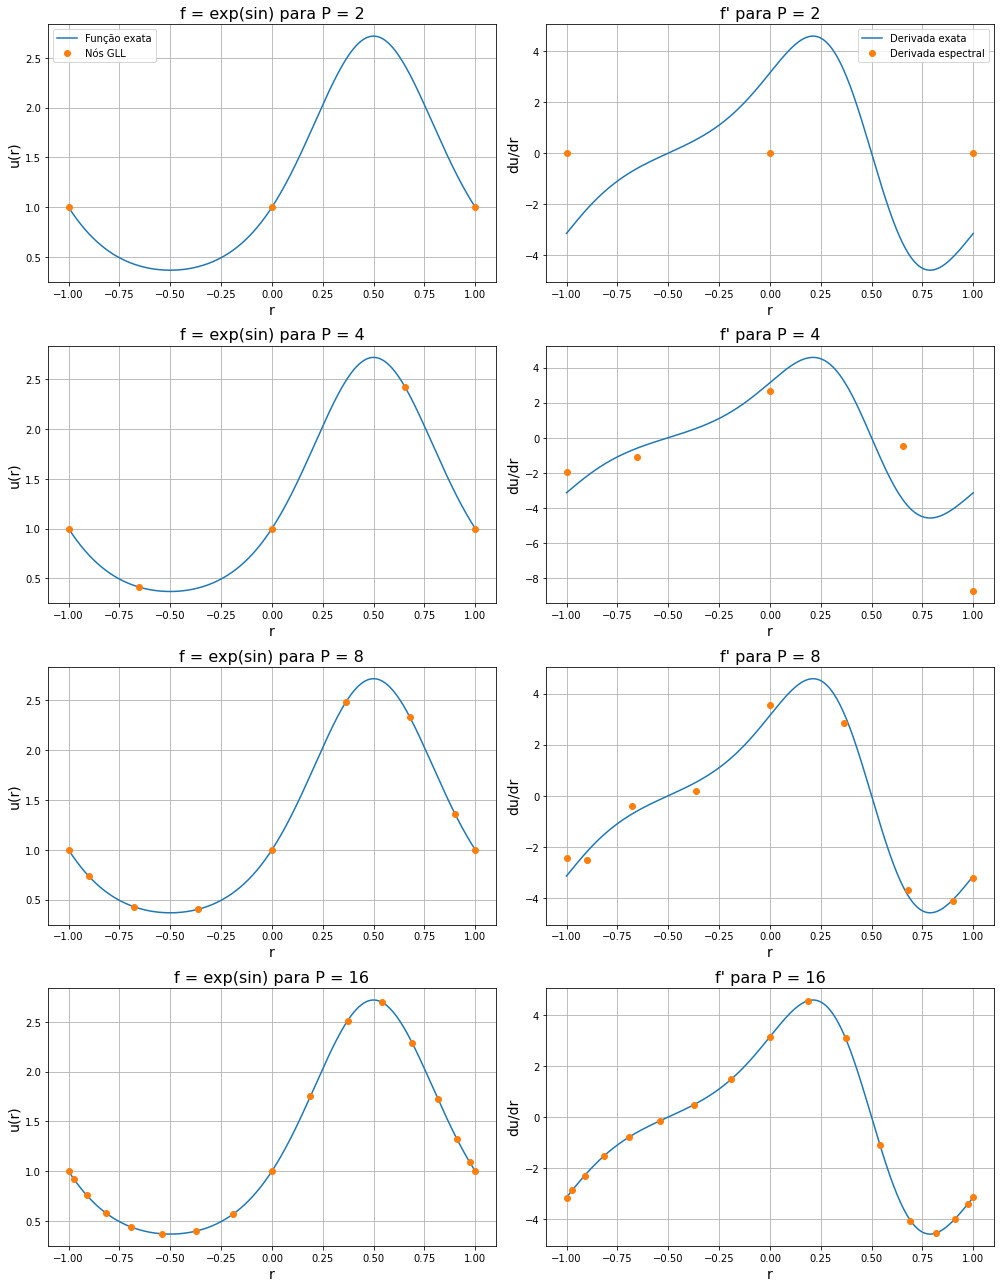

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LISTA DE CASOS PARA TESTE
# -- "Nome" : Funcao f(x), Derivada analitica f'(x)
# ==========================================================
cases = {
    "sin": (
        np.sin,
        np.cos
    ),
    "cos": (
        np.cos,
        lambda x: -np.sin(x)
    ),
    "exp": (
        np.exp,
        np.exp
    ),
    "exp*sin": (
        lambda x: np.exp(x)*np.sin(x),
        lambda x: np.exp(x)*(np.sin(x)+np.cos(x))
    ),
    "exp(sin)": (
    lambda x: np.exp(np.sin(np.pi*x)),
    lambda x: np.pi*np.cos(np.pi*x)*np.exp(np.sin(np.pi*x)),
    ),
}

# ==========================================================
# CASO SELECIONADO
caso = "exp(sin)"
f, df = cases[caso]

# ==========================================================
# Valores do grau do polinomio aproximador P para comparação
P_values = [2, 4, 8, 16]        # até quatro valores

fig, axes = plt.subplots(len(P_values), 2,
                         figsize=(14, 4.5*len(P_values)))

for k, p in enumerate(P_values):
    # k -> iteracao
    # p -> grau do polinomio de aproximacao na iteracao k
    r , wi = jacobi_gauss_quad(P = 2*p-1, quad_type='GLL') # Pontos GLL
    Dr = Dmatrix1D(r,p)                                  # Matriz de diferenciação

    # Solução numérica
    u = f(r)
    du_num = Dr @ u

    # Solução exata
    xx = np.linspace(-1,1,500)
    u_exact = f(xx)
    du_exact = df(xx)

    # Subplot da função
    ax = axes[k,0]
    ax.plot(xx,u_exact,label='Função exata')
    ax.plot(r,u,'o',label='Nós GLL')
    ax.set_title(f'f = {caso} para P = {p}',fontsize=16)
    ax.set_xlabel('r',fontsize=14)
    ax.set_ylabel('u(r)',fontsize=14)
    ax.grid(True)

    if k == 0:
        ax.legend()

    # Subplot da derivada
    ax = axes[k,1]
    ax.plot(xx,du_exact,label='Derivada exata')
    ax.plot(r,du_num,'o',label='Derivada espectral')
    ax.set_title(f"f' para P = {p}",fontsize=16)
    ax.set_xlabel('r',fontsize=14)
    ax.set_ylabel("du/dr",fontsize=14)
    ax.grid(True)

    if k == 0:
        ax.legend()

plt.tight_layout()
plt.show()


#### Curva de Convergência

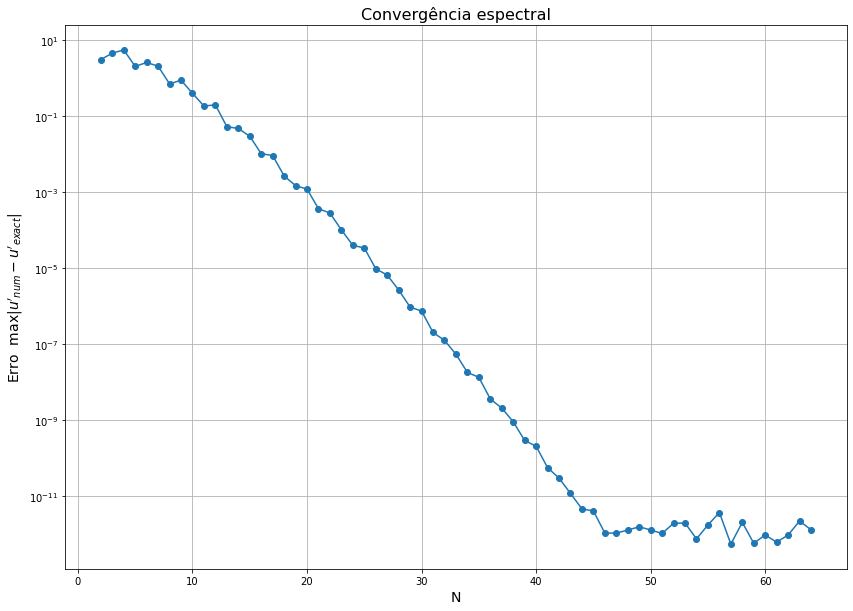

In [33]:
# ==========================================================
# Curva de convergência
# ==========================================================
Ps = np.arange(2,65)   # Grau dos polinomios a serem usados
erro = []

# CASO SELECIONADO
caso = "exp(sin)"
f, df = cases[caso]

for p in Ps:
    r , wi = jacobi_gauss_quad(P = 2*p-1, quad_type='GLL')
    Dr = Dmatrix1D(r,p)
    u = f(r)
    du_num = Dr @ u
    du_exact = df(r)
    erro.append(np.max(np.abs(du_num-du_exact)))

plt.figure(figsize=(14,10))
plt.semilogy(Ps,erro,'o-')
plt.xlabel('N',fontsize=14)
plt.ylabel(r"Erro  $\max|u'_{num} - u'_{exact}|$",fontsize=14)
plt.title('Convergência espectral',fontsize=16)
plt.grid(True,which='both')
plt.show()

## Uso da Matriz de Diferenciação para outros Dominios

Nas **aulas 00** e **02** comentamos sobre a questão de mapeamento e mudança de domínio, em que podemos escrever para o caso 1D:
$$x(\xi) = \frac{(1-\xi)}{2}a + \frac{(1+\xi)}{2}b $$
e manipulando
$$x(\xi) = \frac{(b-a)}{2}\xi + \frac{(a+b)}{2} $$
> **Nota** Nesse notebook $\xi = r$

Sendo nossa função de aproximação escrita da forma:
$$u=u(x(r))$$
como procedemos para calcular a derivada no dominio físico, isto é, como caculamos $\frac{du}{dx}$?

Podemos usar a regra da cadeia, derivando a nossa aproximação com relação a $r$, visto que esse é a matriz de diferenciação $\mathcal{D}_r$:
$$\mathcal{D}_r u = \frac{du}{dr} = \frac{dx}{dr} \frac{du}{dx}  \Longrightarrow \frac{du}{dx} = \frac{dr}{dx}\frac{du}{dr} $$

$$ \boxed{\frac{du}{dx} = \frac{2}{b-a} \mathcal{D}_r u}$$

Vamos exemplificar como fica o uso no caso de querermos avaliar o dominio fisico.

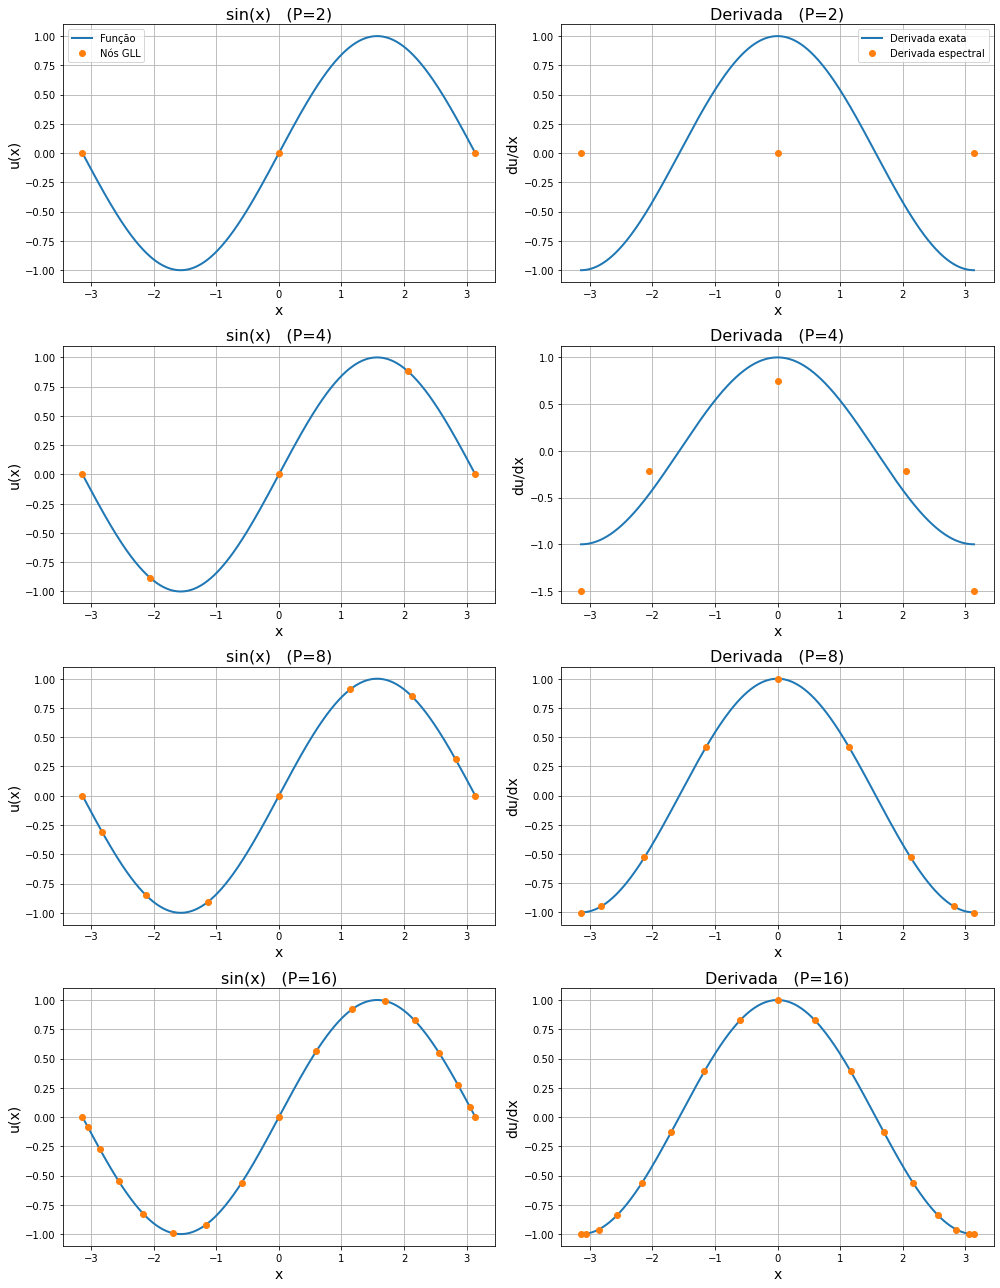

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# LISTA DE CASOS PARA TESTE
# Formato:
# nome : (função, derivada, (a,b))
# ==========================================================
cases2 = {
    "sin(x)": (
        np.sin,
        np.cos,
        (-np.pi, np.pi)
    ),

    "cos(x)": (
        np.cos,
        lambda x: -np.sin(x),
        (-np.pi, np.pi)
    ),

    "exp(x)sin(x)": (
        lambda x: np.exp(x)*np.sin(x),
        lambda x: np.exp(x)*(np.sin(x)+np.cos(x)),
        (-4.6,4.6)
    ),

    "x^3-2x+1": (
        lambda x: x**3 - 2*x + 1,
        lambda x: 3*x**2 - 2,
        (-2,2)
    ),

    "Runge": (
        lambda x: 1/(1+25*x**2),
        lambda x: -50*x/(1+25*x**2)**2,
        (-1,1)
    )
}

# CASO ESCOLHIDO
caso = "sin(x)"
f, df, dominio = cases2[caso]
a, b = dominio

# Valores de P
P_values = [2,4,8,16]
#N_values = [4,16,20,30]

fig, axes = plt.subplots(
    len(P_values),
    2,
    figsize=(14,4.5*len(P_values))
)

for k, p in enumerate(P_values):
    r, wi = jacobi_gauss_quad(P=2*p-1,quad_type="GLL")  # Pontos GLL no elemento de referência
    x = (a+b)/2 + (b-a)/2*r                           # Mapeamento para o domínio físico
    Dr = Dmatrix1D(r,p)                               # Matriz de diferenciação no elemento de referência
    u = f(x)                                          # Valores da função
    du_num = (2/(b-a))*(Dr @ u)                       # Derivada espectral (regra da cadeia)

    # Solução exata
    xx = np.linspace(a,b,600)
    u_exact = f(xx)
    du_exact = df(xx)

    # Plot da Funcao
    ax = axes[k,0]
    ax.plot(xx,u_exact, lw=2, label="Função")
    ax.plot(x,u,'o',ms=6,label="Nós GLL")
    ax.set_title(f"{caso}   (P={p})",fontsize=16)
    ax.set_xlabel("x",fontsize=14)
    ax.set_ylabel("u(x)",fontsize=14)
    ax.grid(True)

    if k == 0:
        ax.legend()

    # Plot da Derivada
    ax = axes[k,1]
    ax.plot(xx,du_exact, lw=2, label="Derivada exata")
    ax.plot(x,du_num, 'o', ms=6, label="Derivada espectral")
    ax.set_title(f"Derivada   (P={p})",fontsize=16)
    ax.set_xlabel("x",fontsize=14)
    ax.set_ylabel("du/dx",fontsize=14)
    ax.grid(True)

    if k == 0:
        ax.legend()

plt.tight_layout()
plt.show()

# **Demonstrações**

### **Por que derivamos a relação** $\mathcal{V}^T \boldsymbol{\ell}(r) = \tilde{\mathbf{P}}(r)$?

Os operadores $\mathcal{M}^k$ e $\mathcal{S}^k$ que são a matriz de massa e rigidez, respectivamente, do método de Galerkin Descontínuo (DG) na versão nodal são definidos por:

#### Matriz de Massa

No elemento físico $D^k=[x_l^k,x_r^k]$, a matriz de massa é definida por

$$ \mathcal{M}_{ij}^k = \int_{x_l^k}^{x_r^k} \ell_i^k(x)\,\ell_j^k(x)\,dx, $$

onde $\ell_i^k(x)$ são os polinômios interpoladores de Lagrange do elemento $k$.

Utilizando o mapeamento afim

$$ x(r)=x_l^k+\frac{1+r}{2}h_k, \qquad h_k=x_r^k-x_l^k, $$
tem-se

$$ dx=\frac{h_k}{2}dr, $$
de modo que

$$ \mathcal{M}_{ij}^k = \frac{h_k}{2} \int_{-1}^{1} \ell_i(r)\,\ell_j(r)\,dr. $$

Define-se então a matriz de massa no elemento de referência
$$ M_{ij} = \int_{-1}^{1} \ell_i(r)\,\ell_j(r)\,dr,$$

obtendo-se
$$ \boxed{\mathcal{M}^k= \frac{h_k}{2}M.}$$

Como os polinômios nodais podem ser escritos em função da base modal ortonormal,

$$ \ell_i(r) = \sum_{n=1}^{N_p} (\mathcal{V}^T)^{-1}_{in}\, \tilde P_{n-1}(r), $$

e utilizando a ortonormalidade dos polinômios de Legendre,
$$(\tilde P_n,\tilde P_m)_I=\delta_{nm},$$

segue que
$$ M = (\mathcal{V}\mathcal{V}^T)^{-1}. $$

Assim,
$$ \boxed{ \mathcal{M}^k = \frac{h_k}{2}(\mathcal{VV}^T)^{-1}.} $$

---

#### Matriz de Rigidez

A matriz de rigidez é definida no elemento físico como

$$ \mathcal{S}_{ij}^k = \int_{x_l^k}^{x_r^k}
\ell_i^k(x) \frac{d\ell_j^k(x)}{dx} \,dx. $$

Aplicando o mapeamento para o elemento de referência,

$$ \frac{d}{dx} = \frac{2}{h_k}\frac{d}{dr}, \qquad dx=\frac{h_k}{2}dr, $$

os fatores métricos se cancelam, resultando em

$$ \mathcal{S}_{ij}^k = \int_{-1}^{1} \ell_i(r) \frac{d\ell_j(r)}{dr} \,dr. $$

Define-se então a matriz de rigidez no elemento de referência como

$$S_{ij} = \int_{-1}^{1} \ell_i(r) \frac{d\ell_j(r)}{dr} \,dr, $$

de modo que

$$ \boxed{\mathcal{S}^k=S.}$$

---

#### Matriz de Diferenciação
Introduz-se a matriz de diferenciação espectral
$$ (\mathcal{D}_r)_{ij} = \left. \frac{d\ell_j}{dr} \right|_{r=r_i}, $$

que transforma os valores nodais da solução em aproximações para suas derivadas nos próprios nós,
$$ \frac{du_h}{dr} = \mathcal{D}_r\,u_h. $$

A partir da expansão modal dos polinômios de Lagrange obtém-se
$$ \mathcal{V}^T\ell(r)=\tilde P(r), $$

e, derivando ambos os lados,
$$ \mathcal{V}^T \mathcal{D}_r^T = \mathcal{V}_r^T, $$

onde
$$ (\mathcal{V}_r)_{ij} = \left. \frac{d\tilde P_j}{dr} \right|_{r=r_i}. $$

Logo,
$$ \boxed{\mathcal{D}_r = \mathcal{V}_r\mathcal{V}^{-1}.} $$

---
Finalmente, utilizando a propriedade de interpolação dos polinômios de Lagrange, demonstra-se que

$$ (M\mathcal{D}_r)_{ij} = \int_{-1}^{1} \ell_i(r) \frac{d\ell_j(r)}{dr} \,dr = S_{ij}, $$

resultando na importante identidade
$$\boxed{M\mathcal{D}_r=S.} $$